In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import os
import re
from functools import reduce
import osmnx as ox
import copy
from datetime import datetime
import sys
import importlib

import helper_functions.residential_attributes
import helper_functions.mrt_buffer
import helper_functions.data
import helper_functions.DEM
import helper_functions.flood_drainage_work

importlib.reload(helper_functions.residential_attributes)
importlib.reload(helper_functions.mrt_buffer)
importlib.reload(helper_functions.data)
importlib.reload(helper_functions.DEM)
importlib.reload(helper_functions.flood_drainage_work)

import helper_functions.residential_attributes as residential_attributes
import helper_functions.mrt_buffer as mrt_buffer
import helper_functions.data as Data
import helper_functions.DEM as DEM
import helper_functions.flood_drainage_work as FloodDrainage
import helper_functions.utils as utils

c:\Users\hypak\AppData\Local\anaconda3\envs\oxpy313\Lib\site-packages\osgeo\gdal.py:311: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


# Code testing

<Axes: >

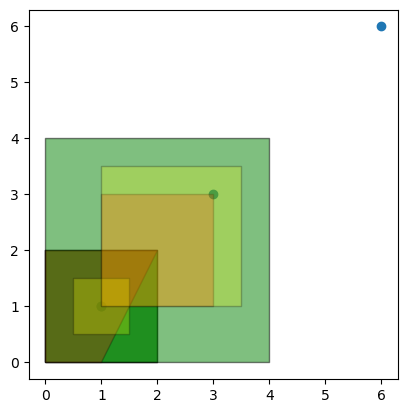

In [2]:
from shapely.geometry import Polygon, LineString, Point
flood_poly = gpd.GeoSeries(
    [
        Polygon([(0, 0), (2,0) ,(2, 2), (0, 2)]),
        Polygon([(0, 0), (2,0), (2, 2), (0, 2)]),
        Polygon([(0, 0), (4,0), (4, 4), (0, 4)])
    ]
)

flood_hotspot_poly = gpd.GeoSeries(
    [
        Polygon([(0.5, 0.5), (1.5,0.5) ,(1.5, 1.5), (0.5, 1.5)]),
        Polygon([(1, 1), (3.5,1), (3.5, 3.5), (1, 3.5)])
    ]
)

property_pts = gpd.GeoSeries(
    [
        Point(1, 1),
        Point(1, 1),
        Point(3, 3),
        Point(6, 6),
    ],
)

adaptation_poly = gpd.GeoSeries(
    [
        Polygon([(0, 0), (1,0) ,(2, 2), (0, 2)]),
        Polygon([(1, 1), (3,1) ,(3, 3), (1, 3)])
    ]
)

flood_df = gpd.GeoDataFrame(data={
    'Flood_Date': pd.to_datetime(['2020-02-01','2020-03-01','2020-05-01']),
    "flooded_location":["A","B","C"]
}, geometry=flood_poly)

flood_hotspot_df = gpd.GeoDataFrame(data={
    'Flood_Hotspot_Date': pd.to_datetime(['2020-01-01','2020-04-01']),
    "flooded_locations":["A","B"]
}, geometry=flood_hotspot_poly)

property_df = gpd.GeoDataFrame(data={
    'Project Name': ['A','A','B','C'],
    'Address': ['A','A','B','C'],
    'ROAD_NAME': ['A','A','B','C'],
    'Sale_Date': pd.to_datetime(['2020-02-01','2020-06-01','2020-02-01','2020-02-01'])},
                               geometry=property_pts)

adaptation_df = gpd.GeoDataFrame(data={
    'work_categories': ['road','drain'],
    'ROAD_NAME': ['A','A'],
    'Drainage_Date': pd.to_datetime(['2020-03-01','2020-07-01'])},
                               geometry=adaptation_poly)
ax = property_df.plot()
flood_df.plot(ax=ax, ec='k', fc='green', alpha=0.5)
adaptation_df.plot(ax=ax, ec='k', fc='red', alpha=0.25)
flood_hotspot_df.plot(ax=ax, ec='k', fc='yellow', alpha=0.25)

In [ ]:
def get_past_work_categories(df,sale_date_column="Sale_Date", event_date_column="Drainage_Date",
                             work_category_column="work_categories"):
    """
    Returns:
        pd.Series (str): identifies work_categories where sale date occurs strictly after Drainage_Date
    """
    past_work = df[sale_date_column] > df[event_date_column]
    past_work_categories = pd.Series(np.nan, dtype="str", index = past_work.index)
    past_work_categories.loc[past_work] = df[work_category_column].loc[past_work]
    return past_work_categories

def get_future_work_categories(df,sale_date_column="Sale_Date", event_date_column="Drainage_Date",
                             work_category_column="work_categories"):
    """
    Returns:
        pd.Series (str): identifies work_categories where sale date occurs before or equals to Drainage_Date
    """
    future_work = df[sale_date_column] <= df[event_date_column]
    future_work_categories = pd.Series(np.nan, dtype="str", index = future_work.index)
    future_work_categories.loc[future_work] = df[work_category_column].loc[future_work]
    return future_work_categories

def get_pre_hotspot_designation_date(df,sale_date_column="Sale_Date", event_date_column="Flood_Hotspot_Date"):
    """
    Returns:
        pd.Series (pd.datetime): identifies Flood_Hotspot_Date where sale date occurs before or equals to Flood_Hotspot_Date
    """
    pre_hotspot = df[sale_date_column] <= df[event_date_column]
    pre_hotspot_designation_date = pd.Series(pd.NaT, index=pre_hotspot.index)
    pre_hotspot_designation_date.loc[pre_hotspot] = df[event_date_column].loc[pre_hotspot]
    return pre_hotspot_designation_date

def get_post_hotspot_designation_date(df,sale_date_column="Sale_Date", event_date_column="Flood_Hotspot_Date"):
    """
    Returns:
        pd.Series (pd.datetime): identifies Flood_Hotspot_Date where sale date occurs strictly after Flood_Hotspot_Date
    """
    post_hotspot = df[sale_date_column] > df[event_date_column]
    post_hotspot_designation_date = pd.Series(pd.NaT, index=post_hotspot.index)
    post_hotspot_designation_date.loc[post_hotspot] = df[event_date_column].loc[post_hotspot]
    return post_hotspot_designation_date

def get_past_flood_count(df,sale_date_column="Sale_Date", event_date_column="Flood_Date"):
    """
    Returns:
        pd.Series (bool): identifies where sale date occurs strictly after flood date
    """
    return df[sale_date_column] > df[event_date_column]

def get_latest_flood_date(df,sale_date_column="Sale_Date", event_date_column="Flood_Date"):
    """
    Returns:
        pd.Series (pd.datetime): identifies flood dates where sale date occurs strictly after flood date
    """
    # only identify rows where sale date occurs strictly after flood date
    post_flood = get_past_flood_count(df,sale_date_column, event_date_column)
    latest_flood_date = pd.Series(pd.NaT, index=post_flood.index)
    latest_flood_date.loc[post_flood] = df[event_date_column].loc[post_flood]
    return latest_flood_date

def get_event_within_months(df,sale_date_column="Sale_Date", event_date_column="Flood_Date", months_after_event=6):
    """
    Assign True/False if transaction occurs within 6 months of event for each groupby_column
    Args:
        df (pd.DataFrame): dataframe after merging event_df to residential df
        sale_date_column (str): name of sale date column
        event_date_column (str): name of event date column e.g. flood or adaptation
        months_after_event (int): months to identify if event occurs within timeframe
    Returns:
        pd.Series: column describing True/False if transaction occurs within 6 months of event
    """
    def months_after_event_func(sale_date, event_date, months_after_event):
        event_date_months_later = event_date + pd.DateOffset(months=months_after_event)
        return (sale_date > event_date) & (sale_date <= event_date_months_later)
    
    def months_before_event_func(sale_date, event_date, months_before_event):
        event_date_months_before = event_date + pd.DateOffset(months=months_before_event)
        return (sale_date <= event_date) & (sale_date >= event_date_months_before)

    if months_after_event > 0:
        post_event_column = months_after_event_func(df[sale_date_column], 
                                                    df[event_date_column], 
                                                    months_after_event)  
    else:
        post_event_column = months_before_event_func(df[sale_date_column], 
                                                df[event_date_column], 
                                                months_after_event)
    
    return post_event_column

def add_historical_flooding(df_property, df_flooding_buffer,
                            months_after_event = [6],
                            sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"]):
    """
    merge with empirical historical flooding data by intersection of locations ONLY
    Args:
        df_property (gpd.GeoDataFrame): df describing property transaction info and property attributes
        df_flooding_buffer (pd.GeoDataFrame): df describing flooding_buffer
        months_after_event (list of int): list of months to identify if event occurs within timeframe
        drop_duplicate_column (list of str): list of columns that identify a unique sale observation
    Returns:
        pd.DataFrame: that adds columns describing whether residential area is within a flood prone area for that year
    """
    df_copy = copy.deepcopy(df_property)
    # merge residential with flood data by location ONLY
    # groupby column is not needed because only areas that intersect with df_flooding_buffer will have non NA flooded_location and Flood_Date data
    # areas that don't intersect with df_flooding_buffer will just have NA values
    residential_flood = df_copy.sjoin(df_flooding_buffer, how="left")
    # add post flood bool col
    for month_after_event in months_after_event:
        residential_flood[f"within_{month_after_event}_months_post_Flood_Date"] = get_event_within_months(residential_flood,sale_date_column=sale_date_column, 
                                event_date_column="Flood_Date", months_after_event=month_after_event)
    # get past flood stats e.g. 'latest_flood_date','past_flood_count','total_flood_count'
    residential_flood['latest_flood_date'] = get_latest_flood_date(residential_flood,sale_date_column=sale_date_column, 
                                event_date_column="Flood_Date")
    residential_flood['past_flood_count'] = get_past_flood_count(residential_flood,sale_date_column=sale_date_column, 
                                event_date_column="Flood_Date")
    # identify obs that have a flood date, which would indicate that a flood occurred
    residential_flood['total_flood_count'] = residential_flood['Flood_Date'].notna()
    # collapse duplicate rows into unique observations
    residential_flood_agg = residential_flood.groupby(drop_duplicate_column).agg({'Flood_Date': lambda x: list(x),
                                                                              'flooded_location': lambda x: list(x),
                                                                              'latest_flood_date': lambda x: x.sort_values(ascending=False).values[0],
                                                                              'past_flood_count': lambda x: x.sum(),
                                                                              'total_flood_count': lambda x: x.sum()
                                                                              } | {f"within_{i}_months_post_Flood_Date": lambda x: x.any() for i in months_after_event}).reset_index()
    
    df_copy = df_copy.merge(residential_flood_agg)
    return df_copy

def add_within_flooding_hotspot_buffer(df_property, df_hotspot_buffer,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"]):
    """
    Args:
        df_property (gpd.GeoDataFrame): df describing property transaction info and property attributes
        df_hotspot_buffer (pd.GeoDataFrame): df describing flooding_hotspot_buffer 
        drop_duplicate_column (list of str): list of columns that identify a unique sale observation
    Returns:
        pd.DataFrame: that adds columns describing whether residential area is within a flood prone area for that year
    """
    df_copy = copy.deepcopy(df_property)
    # merge residential with flood data by location ONLY
    # groupby column is not needed because only areas that intersect with df_hotspot_buffer will have non NA flooded_location and Flood_Date data
    # areas that don't intersect with df_hotspot_buffer will just have NA values
    residential_flood = df_property.sjoin(df_hotspot_buffer, how="left")
    residential_flood['pre_hotspot_designation_date'] = get_pre_hotspot_designation_date(residential_flood,
                                                                                         sale_date_column=sale_date_column,
                                                                                         event_date_column="Flood_Hotspot_Date")
    residential_flood['post_hotspot_designation_date'] = get_post_hotspot_designation_date(residential_flood,
                                                                                         sale_date_column=sale_date_column,
                                                                                         event_date_column="Flood_Hotspot_Date")
    # collapse duplicate rows into unique observations
    residential_flood_agg = residential_flood.groupby(drop_duplicate_column).agg({'Flood_Hotspot_Date': lambda x: list(x),
                                                                              'flooded_locations': lambda x: list(x),
                                                                              'pre_hotspot_designation_date': lambda x: x.sort_values().values[0],
                                                                              'post_hotspot_designation_date': lambda x: x.sort_values(ascending=False).values[0],
                                                                              }).reset_index()
    
    df_copy = df_copy.merge(residential_flood_agg)
    return df_copy

def add_road_drainage_works(df_property, df_road_drainage, sale_date_column="Sale_Date",
                            drop_duplicate_column = ["Project Name","Address","Sale_Date"]):
    """
    Args:
        df_property (gpd.GeoDataFrame): df describing property transaction info and property attributes
        df_road_drainage (pd.GeoDataFrame): df describing buffer location of road raising and drainage works
    Returns:
        pd.DataFrame: that adds columns describing whether residential area is within a flood prone area for that year
    """
    df_copy = copy.deepcopy(df_property)
    # merge residential with flood data
    residential_drainage = df_property.sjoin(df_road_drainage, how="left",
                                             rsuffix="drainage",lsuffix="property")
    residential_drainage['past_work_categories'] = get_past_work_categories(residential_drainage,
                                                                                         sale_date_column=sale_date_column,
                                                                                         event_date_column="Drainage_Date",
                                                                                         work_category_column="work_categories")
    residential_drainage['future_work_categories'] = get_future_work_categories(residential_drainage,
                                                                                         sale_date_column=sale_date_column,
                                                                                         event_date_column="Drainage_Date",
                                                                                         work_category_column="work_categories")
    
    # aggregate drainage adaptation events by property location
    residential_drainage_agg = residential_drainage.groupby(drop_duplicate_column).agg({'Drainage_Date': lambda x: list(x),
                                                                                        'work_categories': lambda x: list(x),
                                                                              'ROAD_NAME_drainage': lambda x: list(x),
                                                                              'past_work_categories': lambda x: x.sort_values().str.cat(sep=","),
                                                                              'future_work_categories': lambda x: x.sort_values().str.cat(sep=",")
                                                                              }).reset_index()
    # replace empty strings with none
    residential_drainage_agg = residential_drainage_agg.replace('',"none")
    df_copy = df_copy.merge(residential_drainage_agg)
    
    return df_copy



In [70]:
x = add_historical_flooding(property_df, flood_df,
                            months_after_event=[-6,0,6],
                            sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])

x = add_within_flooding_hotspot_buffer(x, flood_hotspot_df,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
x = add_road_drainage_works(x, adaptation_df, sale_date_column="Sale_Date", drop_duplicate_column = ["Project Name","Address","Sale_Date"])

# for i in [-6,0,6]:
#     x = add_event_within_months(x,sale_date_column="Sale_Date", event_date_column="Flood_Date", months_after_event=i)
# for i in [-2,0,6]:
#     x = FloodDrainage.add_event_within_months(x,sale_date_column="Sale_Date", event_date_column="Drainage_Date", months_after_event=i)

x

,Project Name,Address,ROAD_NAME,Sale_Date,geometry,Flood_Date,flooded_location,latest_flood_date,past_flood_count,total_flood_count,...,within_6_months_post_Flood_Date,Flood_Hotspot_Date,flooded_locations,pre_hotspot_designation_date,post_hotspot_designation_date,Drainage_Date,work_categories,ROAD_NAME_drainage,past_work_categories,future_work_categories
0,A,A,A,2020-02-01,POINT (1 1),"[2020-02-01 00:00:00, 2020-03-01 00:00:00, 202...","[A, B, C]",NaT,0,3,...,False,"[2020-01-01 00:00:00, 2020-04-01 00:00:00]","[A, B]",2020-04-01,2020-01-01,"[2020-03-01 00:00:00, 2020-07-01 00:00:00]","[road, drain]","[A, A]",none,"drain,road"
1,A,A,A,2020-06-01,POINT (1 1),"[2020-02-01 00:00:00, 2020-03-01 00:00:00, 202...","[A, B, C]",2020-05-01,3,3,...,True,"[2020-01-01 00:00:00, 2020-04-01 00:00:00]","[A, B]",NaT,2020-04-01,"[2020-03-01 00:00:00, 2020-07-01 00:00:00]","[road, drain]","[A, A]",road,drain
2,B,B,B,2020-02-01,POINT (3 3),[2020-05-01 00:00:00],[C],NaT,0,1,...,False,[2020-04-01 00:00:00],[B],2020-04-01,NaT,[2020-07-01 00:00:00],[drain],[A],none,drain
3,C,C,C,2020-02-01,POINT (6 6),[NaT],[nan],NaT,0,0,...,False,[NaT],[nan],NaT,NaT,[NaT],[nan],[nan],none,none


In [68]:
x = FloodDrainage.add_historical_flooding(property_df, flood_df,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])

x = FloodDrainage.add_within_flooding_hotspot_buffer(x, flood_hotspot_df,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
x = FloodDrainage.add_road_drainage_works(x, adaptation_df, sale_date_column="Sale_Date", drop_duplicate_column = ["Project Name","Address","Sale_Date"])

for i in [-6,0,6]:
    x = FloodDrainage.add_event_within_months(x,sale_date_column="Sale_Date", event_date_column="Flood_Date", months_after_event=i)
# for i in [-2,0,6]:
#     x = FloodDrainage.FloodDrainage.add_event_within_months(x,sale_date_column="Sale_Date", event_date_column="Drainage_Date", months_after_event=i)

x
# x[['Project Name','Address','ROAD_NAME','Sale_Date','geometry','Flood_Date','flooded_location']]

,Project Name,Address,ROAD_NAME,Sale_Date,geometry,Flood_Date,flooded_location,latest_flood_date,past_flood_count,total_flood_count,...,pre_hotspot_designation_date,post_hotspot_designation_date,Drainage_Date,work_categories,ROAD_NAME_drainage,past_work_categories,future_work_categories,within_-6_months_post_Flood_Date,within_0_months_post_Flood_Date,within_6_months_post_Flood_Date
0,A,A,A,2020-02-01,POINT (1 1),"[2020-02-01 00:00:00, 2020-03-01 00:00:00, 202...","[A, B, C]",NaT,NaN,3.0,...,2020-04-01,2020-01-01,"[2020-03-01 00:00:00, 2020-07-01 00:00:00]","[road, drain]","[A, A]",none,"road,drain",True,True,False
1,A,A,A,2020-06-01,POINT (1 1),"[2020-02-01 00:00:00, 2020-03-01 00:00:00, 202...","[A, B, C]",2020-05-01,3.0,3.0,...,NaT,2020-04-01,"[2020-03-01 00:00:00, 2020-07-01 00:00:00]","[road, drain]","[A, A]",road,drain,False,False,True
2,B,B,B,2020-02-01,POINT (3 3),[2020-05-01 00:00:00],[C],NaT,NaN,1.0,...,2020-04-01,NaT,[2020-07-01 00:00:00],[drain],[A],none,drain,True,False,False
3,C,C,C,2020-02-01,POINT (6 6),[NaT],[nan],NaT,NaN,NaN,...,NaT,NaT,[NaT],[nan],[nan],none,none,False,False,False


In [73]:
buffer=200
G_car = ox.load_graphml(Data.G_CAR_FP)
residential_df = Data.get_private_residential_df(Data.PRIVATE_RESIDENTIAL_FP)
flooding_df = Data.get_flood_buffer(G_car, Data.FLOOD_FP, radius=buffer)
flooding_hotspot_buffer = Data.get_flooding_hotspot_buffer(G_car, Data.FLOODING_HOTSPOT_FP, radius=buffer)
road_raising_works_buffer_df = Data.get_road_raising_buffer_df(G_car, Data.DRAINAGE_WORKS_FP,
                                                               buffer_dist=buffer)
drainage_works_df = Data.get_drain_improvement_buffer_df(G_car, Data.DRAINAGE_WORKS_FP, 
                                                         buffer_dist=buffer)
road_drainage_works = pd.concat([road_raising_works_buffer_df,drainage_works_df])

length of flood_df:  266
length of edges:  266
length of edges:  314
length of edges:  314


c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:410: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  drains_df['work_categories'] = "Improvement to Roadside/Outlet Drains"
c:\Users\hypak\OneDrive - Singapore Management University\Documents\Projects\Risk Assessment\Impact of flood on property prices\helper_functions\data.py:411: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  culvert_df['work_categories'] = "

In [74]:
y = add_historical_flooding(residential_df, flooding_df,
                            months_after_event=[-6,0,6],
                            sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
y = add_within_flooding_hotspot_buffer(y, flooding_hotspot_buffer,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
y = add_road_drainage_works(y, road_drainage_works, sale_date_column="Sale_Date", drop_duplicate_column = ["Project Name","Address","Sale_Date"])

y

,Building Name,Transacted Price ($),Area (SQFT),Unit Price ($ PSF),Sale_Date,Address,Type of Sale,Type of Area,Area (SQM),Unit Price ($ PSM),...,within_6_months_post_Flood_Date,Flood_Hotspot_Date,flooded_locations,pre_hotspot_designation_date,post_hotspot_designation_date,Drainage_Date,work_categories,ROAD_NAME_drainage,past_work_categories,future_work_categories
0,481 YIO CHU KANG ROAD,950000,1151.75,825,2014-01-02,481 YIO CHU KANG ROAD #05-02,Resale,Strata,107.0,8879,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
1,52 HUME AVENUE,1650000,1550.02,1065,2014-01-02,52 HUME AVENUE #01-16,Resale,Strata,144.0,11458,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
2,41 BRIGHT HILL DRIVE,1051000,731.95,1436,2014-01-02,41 BRIGHT HILL DRIVE #14-01,New/Sub Sale,Strata,68.0,15456,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
3,103 HILLVIEW RISE,730000,516.67,1413,2014-01-03,103 HILLVIEW RISE #10-11,New/Sub Sale,Strata,48.0,15208,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
4,628 UPPER THOMSON ROAD,2518000,3035.45,830,2014-01-03,628 UPPER THOMSON ROAD #05-61,Resale,Strata,282.0,8929,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
267447,66 POTONG PASIR AVENUE 1,2300000,1097.93,2095,2025-06-18,66 POTONG PASIR AVENUE 1 #13-30,New/Sub Sale,Strata,102.0,22549,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
267448,19 WOODLANDS AVENUE 6,1600000,1205.57,1327,2025-06-18,19 WOODLANDS AVENUE 6 #05-26,Resale,Strata,112.0,14286,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
267449,46 MOUNT VERNON ROAD,890000,559.73,1590,2025-06-19,46 MOUNT VERNON ROAD #01-47,Resale,Strata,52.0,17115,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none
267450,21 BIDADARI PARK DRIVE,1865000,742.72,2511,2025-06-20,21 BIDADARI PARK DRIVE #10-26,New/Sub Sale,Strata,69.0,27029,...,False,[NaT],[nan],NaT,NaT,[nan],[nan],[nan],none,none


In [ ]:
y = FloodDrainage.add_historical_flooding(residential_df, flooding_df,sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])

y = FloodDrainage.add_within_flooding_hotspot_buffer(y, flooding_hotspot_buffer[['Flood_Hotspot_Date', 'flooded_locations','geometry']],sale_date_column="Sale_Date",
                                       drop_duplicate_column = ["Project Name","Address","Sale_Date"])
y = FloodDrainage.add_road_drainage_works(y, road_drainage_works[["work_categories","ROAD_NAME","geometry","Drainage_Date"]], sale_date_column="Sale_Date", drop_duplicate_column = ["Project Name","Address","Sale_Date"])

for i in [-6,0,6]:
    y = FloodDrainage.add_event_within_months(y,sale_date_column="Sale_Date", event_date_column="Flood_Date", months_after_event=i)
y